In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/loan_risk_prediction_dataset.csv')

In [3]:
print(df.head())
print(df.shape)
print(df.columns.tolist())

   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  
(5000, 10)
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nMissing Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values:
Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

Missing Percentage:
Age                0.00
Income             3.92
LoanAmount         0.00
CreditScore        3.88
YearsExperience    0.00
Gender             0.00
Education          3.96
City               0.00
EmploymentType     0.00
LoanApproved       0.00
dtype: float64


In [6]:

df['Income'] = df['Income'].fillna(df['Income'].median())
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].median())
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

print(df.isnull().sum())

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

/tmp/ipykernel_1426/4285435597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='LoanApproved', palette='Set2')


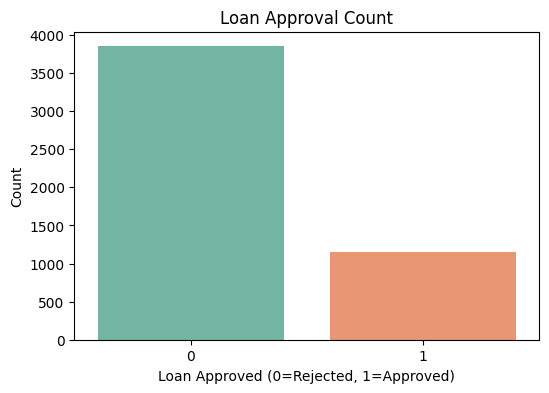

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='LoanApproved', palette='Set2')
plt.title('Loan Approval Count')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1426/3795580051.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='LoanApproved', y='CreditScore', palette='Set1')


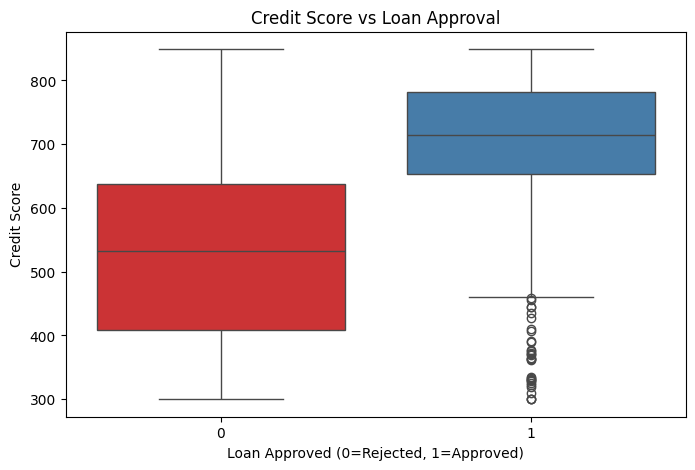

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='LoanApproved', y='CreditScore', palette='Set1')
plt.title('Credit Score vs Loan Approval')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Credit Score')
plt.show()

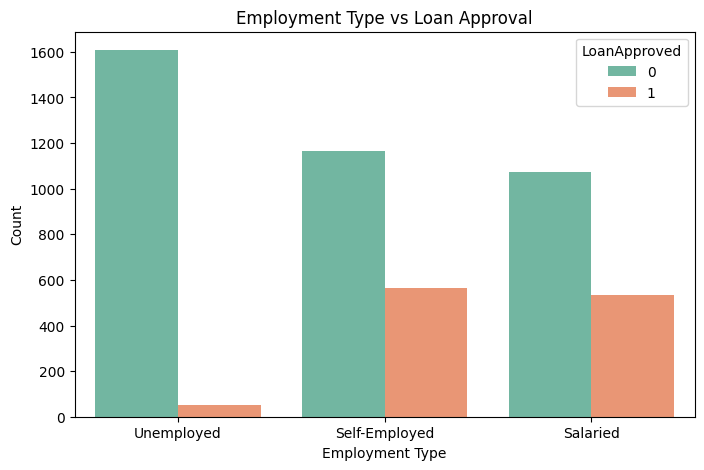

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='EmploymentType', hue='LoanApproved', palette='Set2')
plt.title('Employment Type vs Loan Approval')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.show()

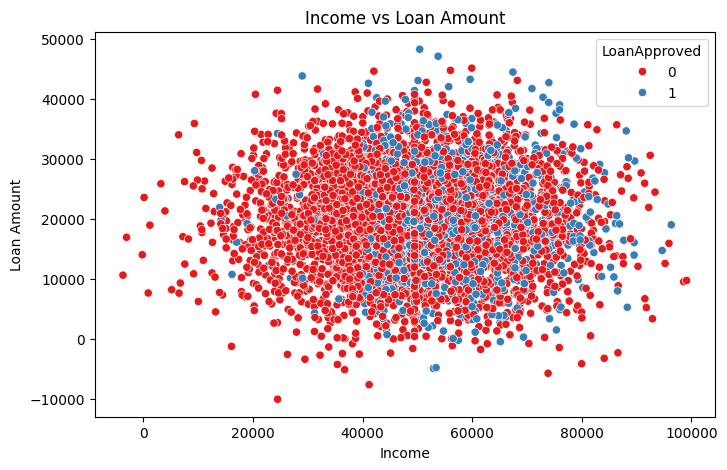

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Income', y='LoanAmount',
                hue='LoanApproved', palette='Set1')
plt.title('Income vs Loan Amount')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.show()

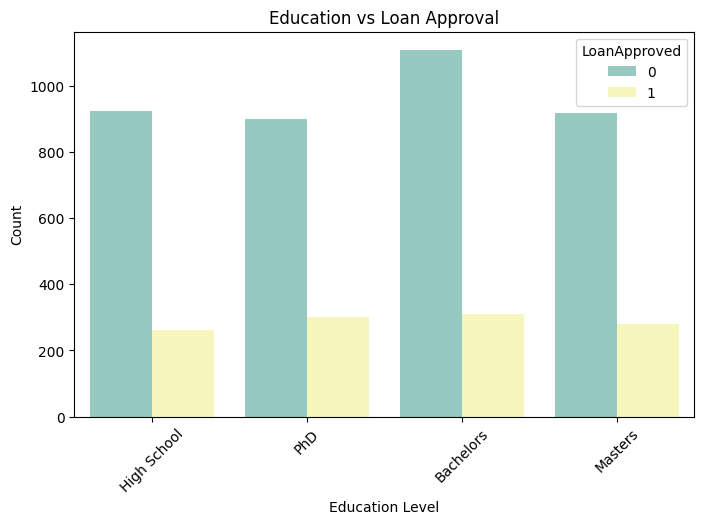

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Education', hue='LoanApproved', palette='Set3')
plt.title('Education vs Loan Approval')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [13]:
df = pd.get_dummies(df, columns=[
    'Gender', 'Education', 'City', 'EmploymentType'
], drop_first=True)

print(df.head())
print(df.shape)

   Age   Income  LoanAmount  CreditScore  YearsExperience  LoanApproved  \
0   56  48353.0     31258.0        675.0               20             0   
1   69  57462.0     23262.0        586.0                6             0   
2   46  44219.0     26530.0        781.0               26             1   
3   32  56307.0     11531.0        549.0               11             0   
4   60  37034.0     27871.0        500.0               19             0   

   Gender_Male  Education_High School  Education_Masters  Education_PhD  \
0        False                   True              False          False   
1         True                   True              False          False   
2         True                  False              False           True   
3         True                  False              False          False   
4        False                   True              False          False   

   City_Houston  City_New York  City_San Francisco  \
0          True          False              

In [14]:
X = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (4000, 14)
Testing size: (1000, 14)


In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Model Accuracy: 85.7 %


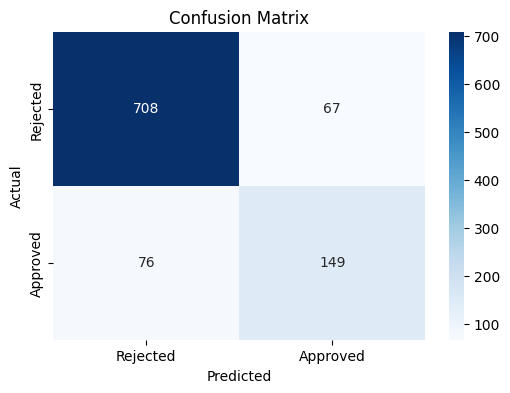

In [16]:

predictions = model.predict(X_test)


accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", round(accuracy * 100, 2), "%")


cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()